In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

#predection
import glob as gb

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


**data preprocessing**

In [2]:
data_dir = "D:\\college\\project\\data set\\xray"
file_paths = []
labels = []

folds = os.listdir(data_dir)

for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    flist =    os.listdir(foldpath)
   
    for f in flist:
        fpath=os.path.join(foldpath,f)
        file_paths.append(fpath)
        labels.append(fold)
        
    
fSeries= pd.Series(file_paths,name='filepaths')
lSeries=pd.Series(labels, name='labels')

df = pd.concat([fSeries , lSeries],axis=1)
df

,filepaths,labels
0,D:\college\project\data set\xray\effussion\000...,effussion
1,D:\college\project\data set\xray\effussion\000...,effussion
2,D:\college\project\data set\xray\effussion\000...,effussion
3,D:\college\project\data set\xray\effussion\000...,effussion
4,D:\college\project\data set\xray\effussion\000...,effussion
...,...,...
7195,D:\college\project\data set\xray\TB\tb-1786.png,TB
7196,D:\college\project\data set\xray\TB\tb-1787.png,TB
7197,D:\college\project\data set\xray\TB\tb-1789.png,TB
7198,D:\college\project\data set\xray\TB\tb-1790.png,TB


**splitting the data**

In [5]:
train_df, ts_df = train_test_split(df,  test_size= 0.2, shuffle= True, random_state= 42,stratify=df['labels'])

# valid and test dataframe

valid_df, test_df = train_test_split(ts_df,  test_size= 0.5, shuffle= True, random_state= 42, stratify=ts_df['labels'])

**image data generator**

In [6]:
# crobed image size
batch_size = 16
img_size = (224, 224)
#channels = 3
#img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 5760 validated image filenames belonging to 4 classes.
Found 720 validated image filenames belonging to 4 classes.
Found 720 validated image filenames belonging to 4 classes.


**model structure**

In [5]:
# # Create Model Structure

# model = Sequential([
    
#     Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape= (224,224,3)),
#     Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
#     Dropout(0.25),
#     MaxPooling2D((2, 2)),
    
#     Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
#     Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
#     Dropout(0.25),
#     MaxPooling2D((2, 2)),
    
#     Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
#     Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
#     Dropout(0.25),
#     MaxPooling2D((2, 2)),
    
#     Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
#     Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
#     Dropout(0.25),
#     MaxPooling2D((2, 2)),
    
#     Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
#     Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
#     Dropout(0.25),
#     MaxPooling2D((2, 2)),
    
#     Flatten(),
#     Dense(256,activation = "relu"),
#     Dropout(0.25),
#     Dense(64,activation = "relu"),
           
#     Dense(4, activation = "softmax") 
# ])

# model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])
# model.summary()    

In [9]:
model = Sequential([
    Conv2D(filters=8, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224,224,1)),
    Conv2D(filters=8, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
    
    
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
    
    
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
 
    
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
   
    
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
    
    
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
    
    
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu" ),
    Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"),
    Dropout(0.25),  # Add dropout with a rate of 25%
    MaxPooling2D((2, 2)),
    
    


    Flatten(),
    Dense(256, activation="relu"),
    Dense(64, activation="relu"),
    Dropout(0.25),
    Dense(4, activation="softmax") 
])


#KerasModel.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'])
#Compile the model
model.compile(optimizer ='Adamax', loss='categorical_crossentropy', metrics=['accuracy'])

#Print the model summary
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_28 (Conv2D)          (None, 224, 224, 8)       80        
                                                                 
 conv2d_29 (Conv2D)          (None, 224, 224, 8)       584       
                                                                 
 dropout_16 (Dropout)        (None, 224, 224, 8)       0         
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 112, 112, 8)       0         
 ng2D)                                                           
                                                                 
 conv2d_30 (Conv2D)          (None, 112, 112, 16)      1168      
                                                                 
 conv2d_31 (Conv2D)          (None, 112, 112, 16)      2320      
                                                      

**pre trained model 1**

In [8]:
# image_size=(224,224)
# channels = 3
# img_shape = (img_size[0], img_size[1], channels)

# base_model = tf.keras.applications.DenseNet169(
# include_top = False,
# weights = "imagenet",
# input_shape = img_shape,)

# model = Sequential([
#     base_model,
#     Flatten(),
#     Dense(256 , activation = 'relu'),
#     Dropout(rate=0.3),
#     Dense(4 , activation ='softmax')
       
# ])
# model.compile(Adamax(learning_rate=0.001) , loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet169 (Functional)    (None, 7, 7, 1664)        12642880  
                                                                 
 flatten (Flatten)           (None, 81536)             0         
                                                                 
 dense (Dense)               (None, 256)               20873472  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 33517380 (127.86 MB)
Trainable params: 33358980 (127.25 MB)
Non-trainable params: 158400 (618.75 KB)
_________________________________________________________________


**pre trained model 2**

In [8]:
# image_size=(224,224)
# channels = 3
# img_shape = (img_size[0], img_size[1], channels)

# base_model = keras.applications.EfficientNetB7(
#     include_top=False,
#     weights="imagenet",
#     input_tensor=None,
#     input_shape = img_shape,
#     classes=4,
#     classifier_activation="softmax"
# )
# model = Sequential([
#     base_model,
#     Flatten(),
#     Dense(256 , activation = 'relu'),
#     Dropout(rate=0.3),
#     Dense(4 , activation ='softmax')
       
# ])
# model.compile(Adamax(learning_rate=0.001) , loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

**training the model**

In [10]:
epochs = 30   # number of all epochs in training

history = model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen)


Epoch 1/30
360/360 [==============================] - 180s 494ms/step - loss: 1.2152 - accuracy: 0.4286 - val_loss: 1.0366 - val_accuracy: 0.6458
Epoch 2/30
360/360 [==============================] - 172s 477ms/step - loss: 0.6251 - accuracy: 0.7321 - val_loss: 0.7859 - val_accuracy: 0.8222
Epoch 3/30
360/360 [==============================] - 171s 475ms/step - loss: 0.4756 - accuracy: 0.8071 - val_loss: 0.7451 - val_accuracy: 0.8389
Epoch 4/30
360/360 [==============================] - 172s 476ms/step - loss: 0.4121 - accuracy: 0.8288 - val_loss: 0.7125 - val_accuracy: 0.8056
Epoch 5/30
360/360 [==============================] - 170s 473ms/step - loss: 0.3919 - accuracy: 0.8382 - val_loss: 0.6507 - val_accuracy: 0.8458
Epoch 6/30
360/360 [==============================] - 170s 472ms/step - loss: 0.3695 - accuracy: 0.8450 - val_loss: 0.5917 - val_accuracy: 0.8139
Epoch 7/30
360/360 [==============================] - 170s 472ms/step - loss: 0.3367 - accuracy: 0.8620 - val_loss: 0.4968 -

**display the modle performance**

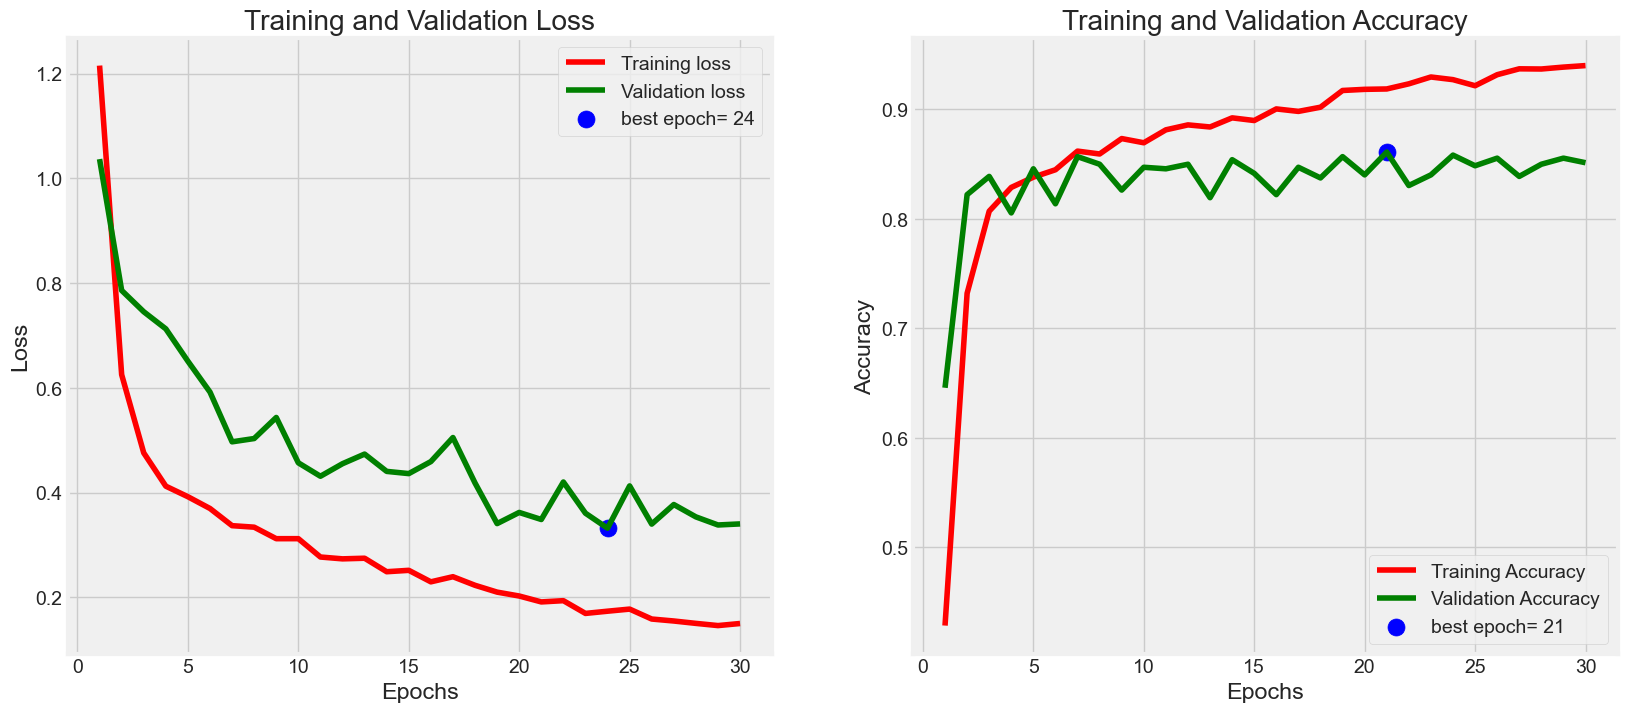

In [11]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

**evaluate the model**

In [12]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

9/9 [==============================] - 2s 234ms/step - loss: 0.2685 - accuracy: 0.9097
Train Loss:  0.25546205043792725
Train Accuracy:  0.9444444179534912
--------------------
Valid Loss:  0.3834506869316101
Valid Accuracy:  0.8263888955116272
--------------------
Test Loss:  0.2684933543205261
Test Accuracy:  0.9097222089767456


**save the model**

In [13]:
#Save the model
model.save("Model.h5")

**predection**

In [16]:

# Load the saved model
model_path = 'model.h5'
loaded_model = tf.keras.models.load_model(model_path)

# Define class labels corresponding to the model's output classes
class_labels = ['normal':0, 'TB':1, 'Mass':2,'effusion':3]  # Replace with your class labels

def getcode(n) :
    for x , y in class_labels.items() :
        if n == y :
            return x

y_result = KerasModel.predict(X_pred_array)

print('Prediction Shape is {}'.format(y_result.shape))


plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(X_pred),2))) : 
    plt.subplot(1,2,n+1)
    plt.imshow(X_pred[i])    
    plt.axis('off')
    plt.title(getcode(np.argmax(y_result[i])))

1/1 [==============================] - 0s 139ms/step
Predicted class: Mass


In [17]:
loaded_model = tf.keras.models.load_model('D:/codes/Model.h5', compile=False)
loaded_model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

In [21]:
image_path = 'd:\codes\CHNCXR_0004_0.png'
image = Image.open(image_path)

# Preprocess the image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, )

# Make predictions
predictions = loaded_model.predict(img_array)
class_labels = ['normal', 'effussion', 'Mass', 'TB']
print(f"{class_labels[np.argmax(predictions)]}")

TypeError: Missing required positional argument